In [1]:
import pandas as pd
import sys
import numpy as np

In [2]:
sys.path.append("..")

In [3]:
from src.data_loader import load_data, save_data_to_csv

In [4]:
data = load_data("QQQ", "2010-01-01", "2026-06-23")

[*********************100%***********************]  1 of 1 completed


In [6]:
start = data.index[0].year
end = data.index[-1].year

end- start

16

In [7]:
start_year = data.index[0].year

train_window = 5
forecast_window = 1

for i in range((data.index[-1].year-data.index[0].year)-train_window + 1):

    train_start = start_year
    train_end = start_year + train_window

    forecast_start = train_end
    forecast_end = forecast_start + forecast_window

    train_data = data[
        (data.index.year >= train_start) &
        (data.index.year < train_end)
    ]

    forecast_data = data[
        (data.index.year >= forecast_start) &
        (data.index.year < forecast_end)
    ]

    print(
        f"Train: {train_start}-{train_end-1}"
    )

    print(
        f"Forecast: {forecast_start}"
    )

    start_year += 1

Train: 2010-2014
Forecast: 2015
Train: 2011-2015
Forecast: 2016
Train: 2012-2016
Forecast: 2017
Train: 2013-2017
Forecast: 2018
Train: 2014-2018
Forecast: 2019
Train: 2015-2019
Forecast: 2020
Train: 2016-2020
Forecast: 2021
Train: 2017-2021
Forecast: 2022
Train: 2018-2022
Forecast: 2023
Train: 2019-2023
Forecast: 2024
Train: 2020-2024
Forecast: 2025
Train: 2021-2025
Forecast: 2026


In [8]:
save_data_to_csv(data, "../data/QQQ_data.csv")

In [6]:
data = pd.read_csv("../data/QQQ_data.csv")

In [7]:
data = data[["Close"]]
data["log_returns"] = np.log(data).diff()

In [8]:
from models.garch import fit_garch_1_1, forecast_garch_1_1_volatility
from models.har import fit_har_rv, forecast_har_rv_volatility 

In [9]:
a = fit_garch_1_1(data[["log_returns"]])

mu          0.104196
omega       0.047105
alpha[1]    0.127277
beta[1]     0.845479
Name: params, dtype: float64

In [13]:
result = forecast_garch_1_1_volatility(a)

In [14]:
result

np.float64(0.01840306436530191)

In [15]:
b = fit_har_rv(data[["log_returns"]])

In [16]:
har_result = forecast_har_rv_volatility(b)

In [17]:
har_result

0.016414464657420188

In [18]:
from models.lstm import create_sequences, fit_lstm, forecast_lstm_volatility

In [19]:
data_train = data[data.index < "2020-01-01"]["log_returns"]

In [20]:
model = fit_lstm(data_train)

In [21]:
model

LSTMVolatilityModel(
  (lstm): LSTM(1, 10, batch_first=True)
  (fc): Linear(in_features=10, out_features=1, bias=True)
)

In [22]:
test_window = data["log_returns"].dropna().iloc[-30:]

forecast = forecast_lstm_volatility(
    model,
    test_window
)

print(forecast)

0.0040331005428014335


In [23]:
from models import egarch, garch, gjr_garch, gru, har, lstm

In [24]:
models_df = pd.DataFrame({
    "model": [
        "GARCH",
        "EGARCH",
        "GJR-GARCH",
        "HAR",
        "LSTM",
        "GRU"
    ],
    "fit_function": [
        garch.fit_garch_1_1,
        egarch.fit_egarch_1_1,
        gjr_garch.fit_gjrgarch_1_1,
        har.fit_har_rv,
        lstm.fit_lstm,
        gru.fit_gru
    ],
    "forecast_function": [
        garch.forecast_garch_1_1_volatility,
        egarch.forecast_egarch_1_1_volatility,
        gjr_garch.forecast_gjrgarch_1_1_volatility,
        har.forecast_har_rv_volatility,
        lstm.forecast_lstm_volatility,
        gru.forecast_gru_volatility
    ]
})

In [25]:
models_df

,model,fit_function,forecast_function
0,GARCH,<function fit_garch_1_1 at 0x0000023837CE3420>,<function forecast_garch_1_1_volatility at 0x0...
1,EGARCH,<function fit_egarch_1_1 at 0x000002385B85E520>,<function forecast_egarch_1_1_volatility at 0x...
2,GJR-GARCH,<function fit_gjrgarch_1_1 at 0x000002385B85EAC0>,<function forecast_gjrgarch_1_1_volatility at ...
3,HAR,<function fit_har_rv at 0x000002384A36FCE0>,<function forecast_har_rv_volatility at 0x0000...
4,LSTM,<function fit_lstm at 0x000002385714D9E0>,<function forecast_lstm_volatility at 0x000002...
5,GRU,<function fit_gru at 0x000002385B83B600>,<function forecast_gru_volatility at 0x0000023...


In [5]:
import sys
sys.path.append("../src")

In [6]:
from training import train_models

In [7]:
result, loss_df = train_models(data)

Train: 2010-2014
Forecast: 2015
Train: 2011-2015
Forecast: 2016
Train: 2012-2016
Forecast: 2017
Train: 2013-2017
Forecast: 2018
Train: 2014-2018
Forecast: 2019
Train: 2015-2019
Forecast: 2020
Train: 2016-2020
Forecast: 2021
Train: 2017-2021
Forecast: 2022
Train: 2018-2022
Forecast: 2023
Train: 2019-2023
Forecast: 2024
Train: 2020-2024
Forecast: 2025
Train: 2021-2025
Forecast: 2026


In [8]:
pivoted = loss_df.pivot(index="epoch", columns=["train_start", "model"], values=["train_loss", "validation_loss"])

<Axes: xlabel='epoch'>

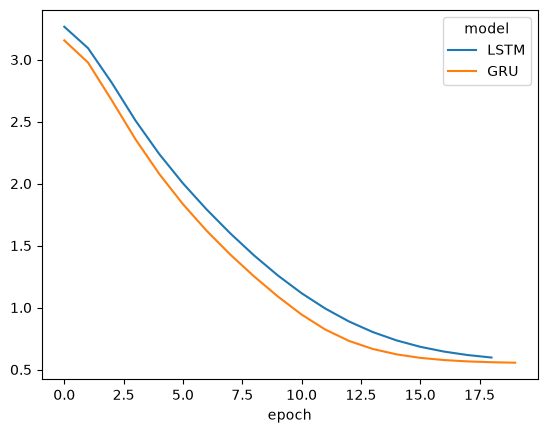

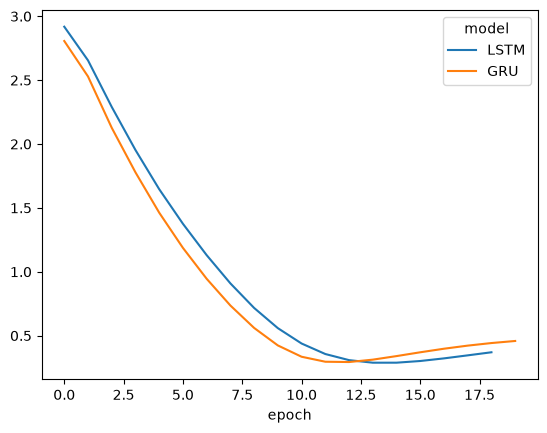

In [9]:
np.log(pivoted["train_loss"][2018]).plot()
np.log(pivoted["validation_loss"][2018]).plot()

<Axes: xlabel='date'>

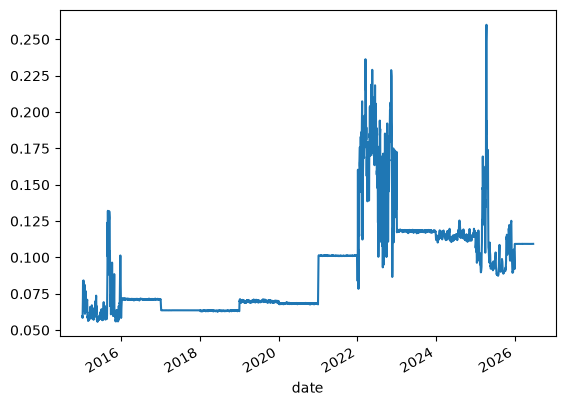

In [13]:
(result["LSTM"] * np.sqrt(252)).plot()

In [10]:
from utils import calculate_log_returns

In [11]:
log_returns = calculate_log_returns(data)

log_returns["log_returns"].abs().describe()

count    4140.000000
mean        0.009037
std         0.009399
min         0.000000
25%         0.002708
50%         0.006389
75%         0.012343
max         0.127592
Name: log_returns, dtype: float64